## Note on Preprocessing
The dataset was scaled using StandardScaler in the DataPreparation notebook.
In production, the scaler should be fit only on training data to avoid data leakage.
Here we load the already preprocessed dataset and apply train/test split for model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

df = pd.read_csv('../data/processed/data_prepared.csv')
print(df.shape)
df.head()

(48514, 168)


,year,condition,odometer,sellingprice,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_double cab,body_e-series van,...,seller_hash_6,seller_hash_7,seller_hash_8,seller_hash_9,seller_hash_10,seller_hash_11,seller_hash_12,seller_hash_13,seller_hash_14,seller_hash_15
0,0.755538,-0.428747,-0.702670,13200.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.520757,0.177594,0.359983,17800.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.245020,0.859728,-0.045250,15700.0,False,False,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.010796,-2.096186,-0.819084,23100.0,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.755538,1.087106,-0.952345,23300.0,False,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [2]:
X = df.drop(columns=['sellingprice'])
y = df['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (38811, 167) Test: (9703, 167)


## Model 1: Linear Regression

In [3]:
param_grid_lr = {'fit_intercept': [True, False]}

lr = GridSearchCV(LinearRegression(), param_grid_lr, cv=3, scoring='r2')
lr.fit(X_train, y_train)

print('Best params:', lr.best_params_)
y_pred_lr = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

Best params: {'fit_intercept': True}
RMSE: 4446.57
MAE: 3303.02
R2: 0.7056


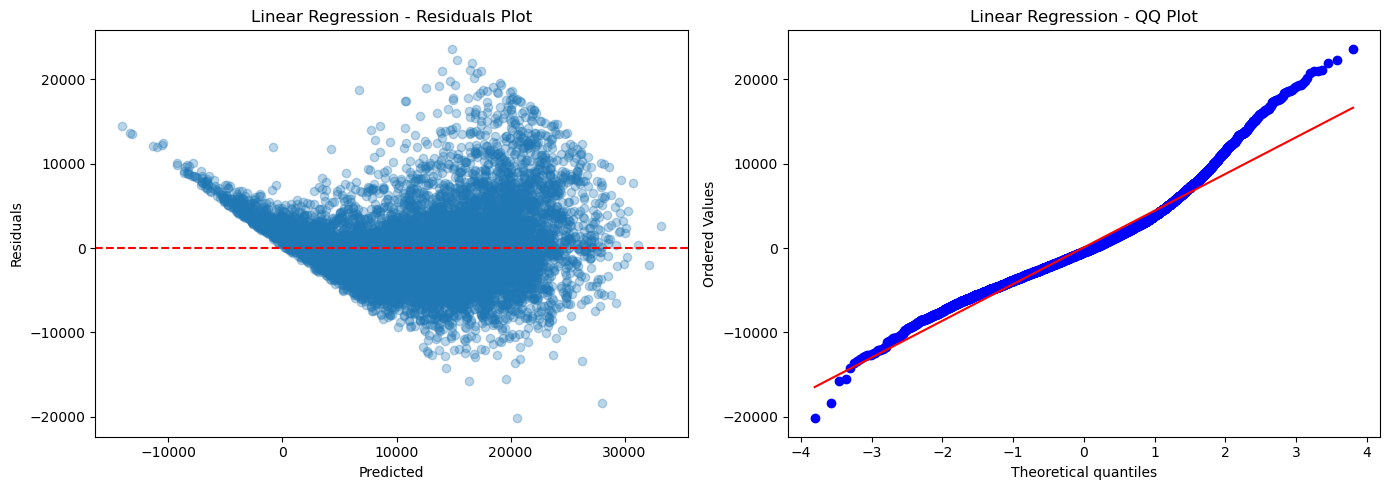

In [4]:
residuals_lr = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals plot
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression - Residuals Plot')

# QQ plot
stats.probplot(residuals_lr, dist='norm', plot=axes[1])
axes[1].set_title('Linear Regression - QQ Plot')

plt.tight_layout()
plt.show()

## Model 2: Decision Tree

In [5]:
param_grid_dt = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=3, scoring='r2')
dt.fit(X_train, y_train)

print('Best params:', dt.best_params_)
y_pred_dt = dt.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

Best params: {'max_depth': 20, 'min_samples_split': 5}
RMSE: 3669.11
MAE: 2427.88
R2: 0.7995


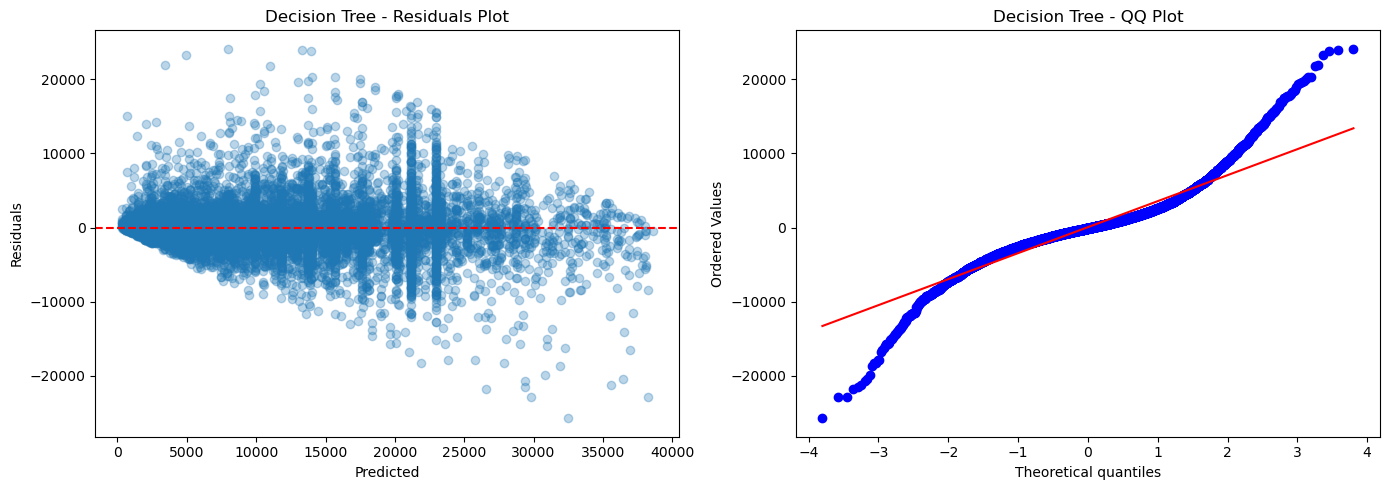

In [6]:
residuals_dt = y_test - y_pred_dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_dt, residuals_dt, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Decision Tree - Residuals Plot')

stats.probplot(residuals_dt, dist='norm', plot=axes[1])
axes[1].set_title('Decision Tree - QQ Plot')

plt.tight_layout()
plt.show()

## Model 3: Random Forest

In [11]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='r2')
rf.fit(X_train, y_train)

print('Best params:', rf.best_params_)
y_pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

Best params: {'max_depth': 20, 'n_estimators': 100}
RMSE: 3109.13
MAE: 2097.77
R2: 0.8561


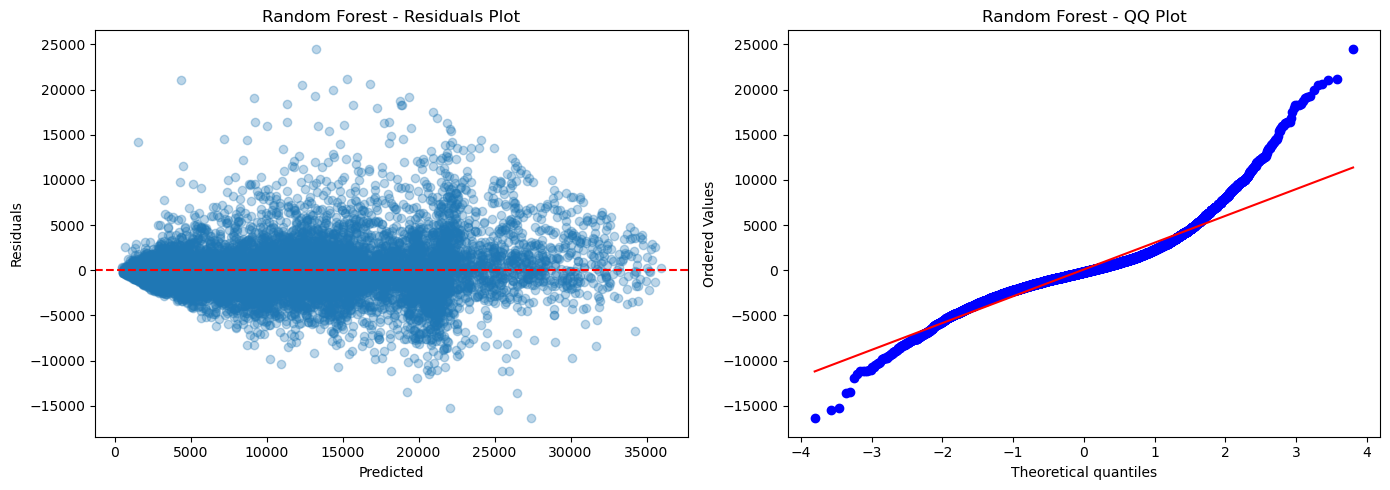

In [12]:
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_rf, residuals_rf, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest - Residuals Plot')

stats.probplot(residuals_rf, dist='norm', plot=axes[1])
axes[1].set_title('Random Forest - QQ Plot')

plt.tight_layout()
plt.show()

## Model 4: Gradient Boosting

In [13]:
param_grid_gb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=3, scoring='r2')
gb.fit(X_train, y_train)

print('Best params:', gb.best_params_)
y_pred_gb = gb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae = mean_absolute_error(y_test, y_pred_gb)
r2 = r2_score(y_test, y_pred_gb)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
RMSE: 3348.66
MAE: 2356.28
R2: 0.8330


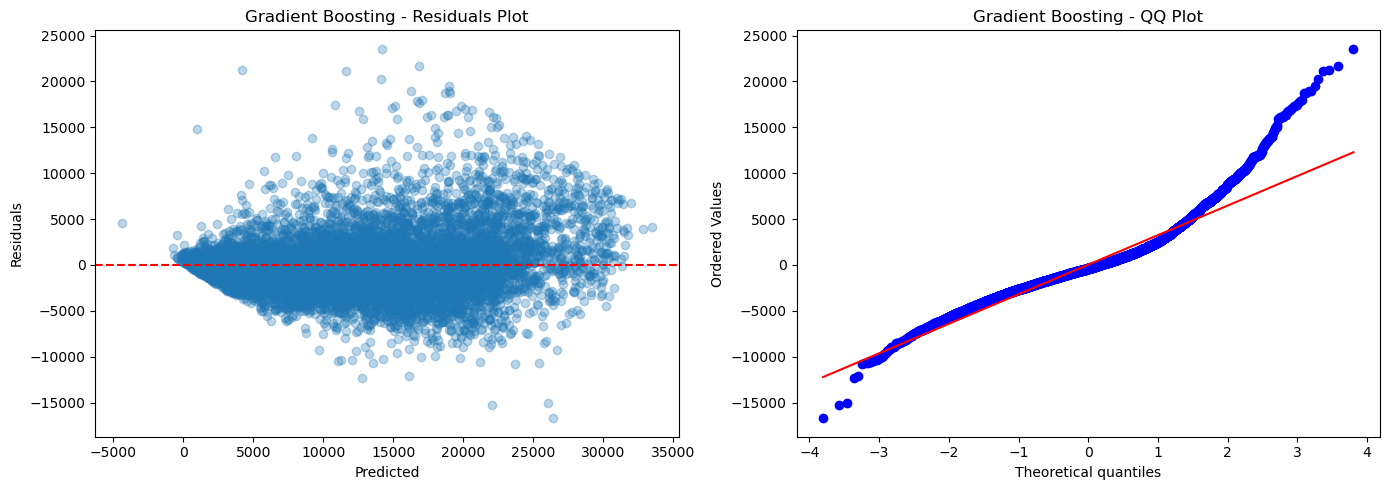

In [14]:
residuals_gb = y_test - y_pred_gb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_gb, residuals_gb, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Gradient Boosting - Residuals Plot')

stats.probplot(residuals_gb, dist='norm', plot=axes[1])
axes[1].set_title('Gradient Boosting - QQ Plot')

plt.tight_layout()
plt.show()

## Best Model

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

print(results)

               Model         RMSE          MAE        R2
0  Linear Regression  4446.565930  3303.015074  0.705584
1      Decision Tree  3669.106033  2427.881245  0.799538
2      Random Forest  3109.126594  2097.769397  0.856057
3  Gradient Boosting  3348.659452  2356.281029  0.833024


## Conclusion

The main metric used for model selection is **R2** (coefficient of determination), 
as it shows how well the model explains the variance in selling price.

| Model | RMSE | MAE | R2 |
|-------|------|-----|----|
| Linear Regression | 4446.57 | 3303.02 | 0.706 |
| Decision Tree | 3669.11 | 2427.88 | 0.800 |
| Random Forest | 3109.13 | 2097.77 | 0.857 |
| Gradient Boosting | 3348.66 | 2356.28 | 0.833 |

**Random Forest** was selected as the best model because:
- Highest R2 = 0.857 — explains 85.7% of price variance
- Lowest RMSE = 3109 — predictions are closest to real prices
- Lowest MAE = 2097 — on average off by ~$2097
- More robust than a single Decision Tree
- Better than Gradient Boosting on all metrics